# AL3 — Morphology & Watershed
**MCS 3950 Computer Vision**

One thread runs through all three parts. **Part 1** shows what a morphological
opening really keeps. **Part 2** uses the distance transform and watershed to
count golf balls that touch, which is exactly the problem these tools were built
for. **Part 3** runs the same tools on 1935 farm fields, where they return a
confident answer you should not believe until you have audited it.

Each part has a **task** you implement and **checkpoint questions** you answer
in the cells provided.

| Part | Topic | Time |
|------|-------|------|
| 1 | Structuring elements: what opening actually keeps | ~10 min |
| 2 | Watershed where it works: counting golf balls that touch | ~20 min |
| 3 | Watershed where it doesn't: measuring 1935 fields | ~20 min |
| ★ | Bonus: how a distance-transform peak becomes one seed | if time |

> **Not submitted or graded.** Hands-on practice with the morphology, distance
> transform and watershed from L5, before Test 1.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

def show(images, titles, cmap='gray', vmin=0, vmax=255, figw=15, figh=4):
    fig, axes = plt.subplots(1, len(images), figsize=(figw, figh))
    if len(images) == 1: axes = [axes]
    for ax, im, t in zip(axes, images, titles):
        colour = im.ndim == 3
        ax.imshow(im, cmap=None if colour else cmap,
                  vmin=None if colour else vmin, vmax=None if colour else vmax)
        ax.set_title(t, fontsize=11); ax.axis('off')
    plt.tight_layout(); plt.show()

def se(shape, n):
    """Structuring element: 'rect', 'ellipse' or 'cross', size n x n."""
    kinds = {'rect': cv2.MORPH_RECT, 'ellipse': cv2.MORPH_ELLIPSE,
             'cross': cv2.MORPH_CROSS}
    return cv2.getStructuringElement(kinds[shape], (n, n))

def tint(img, mask, colour, a=0.45):
    """Overlay a boolean mask on an image (gray or RGB) in the given colour."""
    out = (cv2.cvtColor(img, cv2.COLOR_GRAY2RGB) if img.ndim == 2 else img).astype(float)
    out[mask] = out[mask]*(1 - a) + np.array(colour)*a
    return out.astype(np.uint8)

print("Setup complete.")

Setup complete.


## Get the imagery

The grayscale clips from AL2, and a photograph of golf balls in grass.

  3.1 MB — three clips extracted
  downloaded golf_balls.jpg

historical clips: 800 x 800 px at 1 m/px
golf balls      : 900 x 1200 px


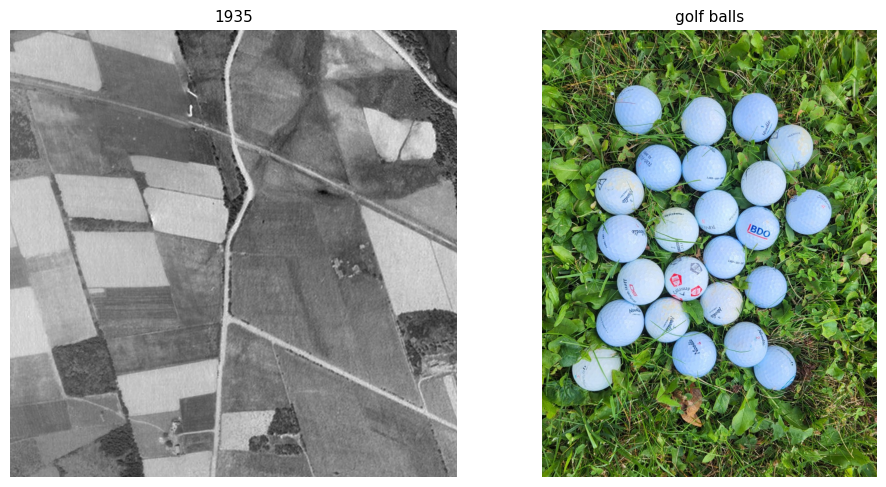

In [3]:
import io, os, urllib.request, zipfile

BASE = ("https://raw.githubusercontent.com/andrewgodbout/"
        "MCS-3950-F26/main/Notebooks/data/")

NEEDED = ["pei_1935.png", "pei_1958.png", "pei_1968.png"]
if all(os.path.exists(f) for f in NEEDED):
    print("Historical clips already present.")
else:
    with urllib.request.urlopen(BASE + "AL2.zip", timeout=60) as r:
        blob = r.read()
    with zipfile.ZipFile(io.BytesIO(blob)) as z:
        z.extractall(".")
    print(f"  {len(blob)/1e6:.1f} MB — three clips extracted")

if not os.path.exists("golf_balls.jpg"):
    urllib.request.urlretrieve(BASE + "golf_balls.jpg", "golf_balls.jpg")
    print("  downloaded golf_balls.jpg")
else:
    print("golf_balls.jpg already present.")

# ── put the historical clips on a common 1 m/px grid (as in AL2) ────────────
RES = {1935: 0.5, 1958: 1.1593543264609192, 1968: 0.5}
YEARS = [1935, 1958, 1968]

def to_grid(img, src_res, target=1.0):
    s = src_res / target
    wh = (int(round(img.shape[1]*s)), int(round(img.shape[0]*s)))
    return cv2.resize(img, wh, interpolation=cv2.INTER_AREA if s < 1 else cv2.INTER_CUBIC)

aerial = {y: to_grid(cv2.imread(f"pei_{y}.png", cv2.IMREAD_GRAYSCALE), RES[y]) for y in YEARS}
side = min(min(a.shape) for a in aerial.values())
aerial = {y: a[:side, :side] for y, a in aerial.items()}

balls_bgr = cv2.imread("golf_balls.jpg")
balls = cv2.cvtColor(balls_bgr, cv2.COLOR_BGR2RGB)

print(f"\nhistorical clips: {side} x {side} px at 1 m/px")
print(f"golf balls      : {balls.shape[1]} x {balls.shape[0]} px")
show([aerial[1935], balls], ["1935", "golf balls"], figw=10, figh=5)

---
## Part 1 — Structuring Elements  `⏱ ~10 min`

Morphology works on **binary** images and asks one question at every pixel:

> **does the structuring element fit here?**

The *structuring element* (SE) is a small shape (a square, a disk, a long thin
line) that you slide over the image like a convolution kernel, except the
arithmetic is replaced by set logic.

| Operation | Rule | Effect |
|---|---|---|
| **Erosion** | keep a pixel only if the SE fits **entirely** inside the foreground | shrinks objects, deletes anything smaller than the SE |
| **Dilation** | keep a pixel if the SE touches the foreground **at all** | grows objects, fills small gaps |
| **Opening** | erode, *then* dilate | removes small specks, keeps big shapes at roughly their original size |
| **Closing** | dilate, *then* erode | fills small holes and cracks, keeps big shapes at roughly their original size |

The test mask below has a big square with a small hole, a speck, and two blocks
joined by a thin bridge.

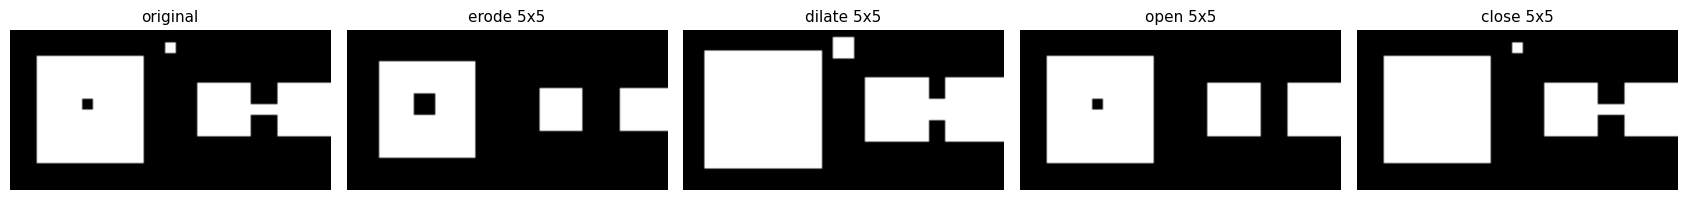

Check each panel against the table:
  erosion  - speck gone, square smaller, hole bigger, bridge cut
  dilation - hole filled, square bigger, speck bigger
  opening  - speck and bridge gone, square back to its original size
  closing  - hole filled, square back to its original size

The hole is 4x4 on purpose. A 5x5 closing dilates by 2 px on every side, so it
can seal holes up to 4 px across. Make the hole 5x5 and the closing leaves it
untouched. Size relative to the structuring element is the whole game.


In [4]:
demo = np.zeros((60, 120), np.uint8)
demo[10:50, 10:50] = 255          # big square
demo[26:30, 27:31] = 0            # 4x4 hole inside it
demo[5:9,  58:62]  = 255          # small speck
demo[20:40, 70:90] = 255          # block A
demo[20:40, 100:120] = 255        # block B
demo[28:32, 90:100] = 255         # thin bridge joining A and B (4 px tall)

k = se('rect', 5)
show([demo, cv2.erode(demo, k), cv2.dilate(demo, k),
      cv2.morphologyEx(demo, cv2.MORPH_OPEN, k), cv2.morphologyEx(demo, cv2.MORPH_CLOSE, k)],
     ["original", "erode 5x5", "dilate 5x5", "open 5x5", "close 5x5"], figw=17, figh=2.6)

print("Check each panel against the table:")
print("  erosion  - speck gone, square smaller, hole bigger, bridge cut")
print("  dilation - hole filled, square bigger, speck bigger")
print("  opening  - speck and bridge gone, square back to its original size")
print("  closing  - hole filled, square back to its original size")
print()
print("The hole is 4x4 on purpose. A 5x5 closing dilates by 2 px on every side, so it")
print("can seal holes up to 4 px across. Make the hole 5x5 and the closing leaves it")
print("untouched. Size relative to the structuring element is the whole game.")

### Task 1 — does the *shape* of the SE matter?

Perform an *open* on the `demo` image with four SEs: a 9×9 square, a 9×9 ellipse, a 9×9 cross, and a long
thin 15×3 rectangle.

Run the below code block to see each of the 4 SEs displayed so you gain an understanding of their shape.

In the first code block (above) we defined a method called `se` that returns a specified structuring element kernel from various shapes (cross, ellipse and square) and sizes:

```python
def se(shape, n):
    """Structuring element: 'rect', 'ellipse' or 'cross', size n x n."""
    kinds = {'rect': cv2.MORPH_RECT, 'ellipse': cv2.MORPH_ELLIPSE,
             'cross': cv2.MORPH_CROSS}
    return cv2.getStructuringElement(kinds[shape], (n, n))

```

First run the below code to visualize the different SEs.

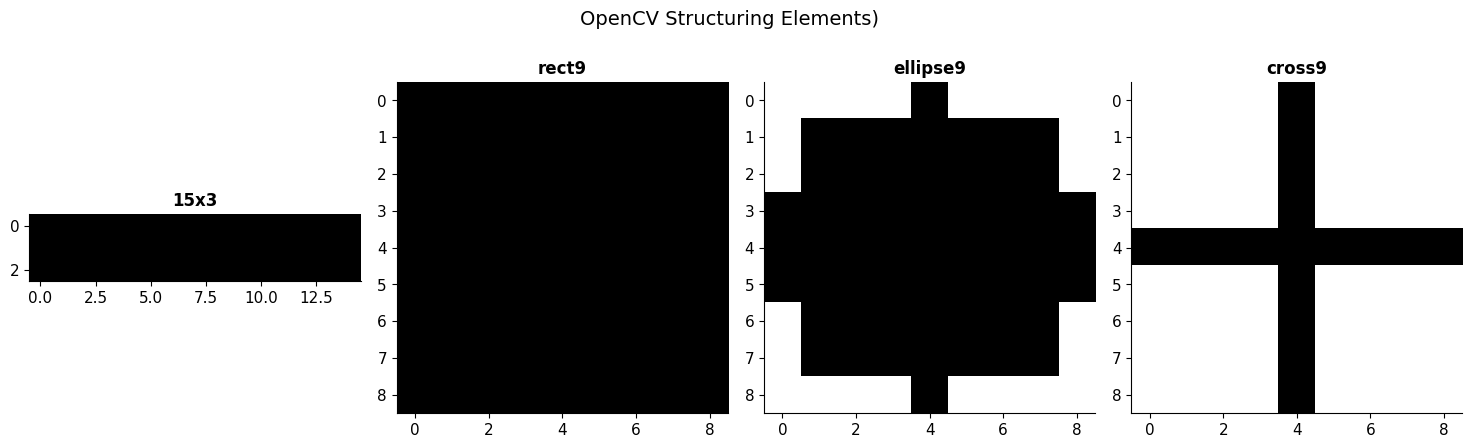

In [6]:
kernels = {
    '15x3': cv2.getStructuringElement(cv2.MORPH_RECT, (15, 3)),   # 15 wide, 3 tall
    'rect9': se('rect', 9),
    'ellipse9': se('ellipse', 9),
    'cross9': se('cross', 9)
}

# first display each of the SEs:


# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

# Loop through the shapes and plot them
for ax, (name, k) in zip(axes, kernels.items()):

    # Display the kernel as a grid image
    ax.imshow(k, cmap='gray_r', interpolation='nearest',  vmin=0, vmax=1, aspect='equal') # 'gray_r' makes 1s dark and 0s white
    ax.set_title(name, fontsize=12, fontweight='bold')

    # Add minor gridlines to cleanly show individual pixel boundaries
    #ax.set_xticks([x - 0.5 for x in range(1, 10)], minor=True)
    #ax.set_yticks([y - 0.5 for y in range(1, 10)], minor=True)
    #ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)
    #ax.set_axis_off()
    # Clean up axes ticks
    #ax.set_xticks(range(10))
    #ax.set_yticks(range(10))

plt.suptitle(f"OpenCV Structuring Elements)", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()


### Perform the Open

In the first code block (top) we defined a method called `se` that returns a specified structuring element kernel from various shapes (cross, ellipse and square) and sizes (it is also called in the above code block):

```python
def se(shape, n):
    """Structuring element: 'rect', 'ellipse' or 'cross', size n x n."""
    kinds = {'rect': cv2.MORPH_RECT, 'ellipse': cv2.MORPH_ELLIPSE,
             'cross': cv2.MORPH_CROSS}
    return cv2.getStructuringElement(kinds[shape], (n, n))

```

Your task: in the below opened dictionary, associate a morphology operation call with a simple name (akin to how it was done in the above display code).

You can call a morphology operation from cv2 using the following method:

```python
cv2.morphologyEx(src, op, kernel)
```

where:
`src` is the source image (in our case `demo`),
`op` is the operation in our case open: `cv2.MORPH_OPEN`, and
`kernel` is the SE kernel that our `se` method gives us.

Lastly, Assess the result of applying the SE in an OPEN operation to the demo image in the below questions.

In [ ]:
k_wide = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 3))

# ── YOUR CODE HERE ──────────────────────────────────────────────────────────
# Fill `opened` with four entries, each an opening of `demo`:
#   "rect 9",            "ellipse 9"
#   "cross 9",           "15x3"
# e.g.  opened["rect 9"] = cv2.morphologyEx(demo, cv2.MORPH_OPEN, se('rect', 9))
opened = {
  "rect 9": cv2.morphologyEx(demo, cv2.MORPH_OPEN, se("rect", 9)),
  "elipse 9": cv2.morphologyEx(demo, cv2.MORPH_OPEN, se("elipse", 9)),
  "croos 9": cv2.morphologyEx(demo, cv2.MORPH_OPEN, se("cross", 9)),
  "15x3": cv2.morphologyEx(demo, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (15, 3))),
}
if len(opened) < 4:
    print("Complete Task 1: fill in all four openings.")
else:
    parts = {"big square": (slice(10, 50), slice(10, 50)), "speck": (slice(5, 9), slice(58, 62)),
             "block A": (slice(20, 40), slice(70, 90)), "bridge": (slice(28, 32), slice(90, 100)),
             "block B": (slice(20, 40), slice(100, 120))}
    show([demo] + list(opened.values()), ["original"] + [f"open {k}" for k in opened],
         figw=17, figh=2.6)
    print(f"{'SE':11}{'kept':>8}   " + "".join(f"{p:>12}" for p in parts))
    print("-" * 72)
    for name, out in opened.items():
        frac = "".join(f"{100*(out[s]>0).sum()/max(1,(demo[s]>0).sum()):11.0f}%" for s in parts.values())
        print(f"{name:11}{100*(out>0).mean():7.2f}%   {frac}")

### Checkpoint 1

**Q1a.** The cross is a *subset* of the 9×9 square (17 pixels against 81), so
you might expect it to erase less. It erases **more**. Why?
*(Hint: opening returns the union of every copy of the SE that fits entirely
inside the shape.)*

*Your answer:*

---

**Q1b.** The bridge is cut clean away by the square, mostly survives the cross,
and survives the 15×3 completely. Account for all three.

*Your answer:*

> **Carry this into Parts 2 and 3:** an SE removes what it cannot fit inside and
> keeps what it can. When you choose a size, you are choosing what counts as
> noise.

---
## Part 2 — Watershed Where It Works: Counting Golf Balls  `⏱ ~20 min`

**Before you run anything, count the golf balls by eye and write your number
here:** ______

We'll build the count in six steps, looking at the photo after each one:

1. a mask that separates balls from grass
2. clean it, then count connected components (and watch it fail)
3. the distance transform: one peak per ball
4. find the peaks (**your task**)
5. seed a watershed from the peaks
6. audit the result ball by ball

### Step 1 · A mask: bright *and* colourless

In HSV (L2), a golf ball is **bright** (high V) and **colourless** (low S).
Sunlit grass and pale dead leaves are bright too, but they carry colour. So
`V − S` is high on balls and lower on everything else. The orange pixels in the
second figure are what brightness alone would have let in.

In [ ]:
hsv_b = cv2.cvtColor(balls_bgr, cv2.COLOR_BGR2HSV)
Sb = hsv_b[:, :, 1]
Vb = hsv_b[:, :, 2]
score = cv2.normalize(Vb.astype(float) - Sb.astype(float), None, 0, 255,
                      cv2.NORM_MINMAX).astype(np.uint8)

t_v,  mask_v = cv2.threshold(cv2.GaussianBlur(Vb,    (0, 0), 3), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
thr_b, mask_b = cv2.threshold(cv2.GaussianBlur(score, (0, 0), 3), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

show([balls, Vb, Sb, score], ["photo", "V (brightness)", "S (saturation)", "V − S"],
     figw=16, figh=5)
only_v = (mask_v > 0) & (mask_b == 0)
show([tint(balls, mask_b > 0, [255, 0, 255], 0.5), tint(balls, only_v, [255, 140, 0], 0.8)],
     [f"Otsu on V − S (t = {thr_b:.0f}): {100*(mask_b>0).mean():.1f}% of the photo",
      f"orange: what Otsu on V alone would ALSO call ball ({100*only_v.mean():.1f}%)"],
     figw=12, figh=7)

### Step 2 · Clean the mask, then count connected components

Two clean-up steps, both using Part 1's idea of *size relative to the SE*:

- **Open with a 5-px disk** to delete grass specks smaller than the disk.
- **Fill small holes.** A printed logo can leave a hole inside a ball. But the
  gaps *between* touching balls are holes too, and filling those would weld the
  balls together. So `clean_mask` only fills holes smaller than `HOLE_FRAC` of
  one ball's area.

The cell prints what each step changed and colours every hole in the mask. Then
`cv2.connectedComponentsWithStats` labels each separate blob, keeping blobs of at
least 0.3 of a ball. Each colour in the last figure is one component.

In [ ]:
BALL_R = 60.0                        # ball radius in pixels, at this image size
BALL_AREA = np.pi * BALL_R**2
HOLE_FRAC = 0.12                     # fill holes smaller than 12% of one ball

def find_holes(m):
    """Label the holes in a mask: background that doesn't connect to the image border."""
    ff = m.copy()                    # flood the outside from a corner...
    cv2.floodFill(ff, np.zeros((m.shape[0]+2, m.shape[1]+2), np.uint8), (0, 0), 255)
    return cv2.connectedComponentsWithStats(cv2.bitwise_not(ff), 8)   # ...what's left is a hole

def clean_mask(mask, close_size=0, hole_frac=HOLE_FRAC):
    """
    Clean a binary mask (255 = ball, 0 = grass): open to remove small
    specks, optionally close, then fill holes smaller than hole_frac of a
    ball (e.g. logos). Larger holes are the gaps between touching balls,
    so they are left open to keep the balls separate.
    """
    m = cv2.morphologyEx(mask, cv2.MORPH_OPEN, se('ellipse', 5))
    if close_size:
        m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, se('ellipse', close_size))
    nh, hl, hs, _ = find_holes(m)
    for i in range(1, nh):
        #label small holes as ball
        if hs[i, cv2.CC_STAT_AREA] < hole_frac * BALL_AREA:
            m[hl == i] = 255
    return m

m = clean_mask(mask_b)

# ── what did each cleaning step change? ─────────────────────────────────────
def count_components(mk):
    n, _, st, _ = cv2.connectedComponentsWithStats(mk, 8)
    return n - 1, int((st[1:, cv2.CC_STAT_AREA] >= 0.3*BALL_AREA).sum())

opened_b = cv2.morphologyEx(mask_b, cv2.MORPH_OPEN, se('ellipse', 5))
print(f"{'mask':20} | {'all components':>14} | {'blobs >= 0.3 ball':>17}")
print("-" * 58)
for name, mk in (("raw Otsu", mask_b), ("after opening", opened_b), ("after hole filling", m)):
    a, b = count_components(mk)
    print(f"{name:20} | {a:>14} | {b:>17}")

# ── the holes, and which ones clean_mask filled ─────────────────────────────
nh, hl, hs, hc = find_holes(opened_b)
vis = balls.copy()
fig, ax = plt.subplots(figsize=(7, 8.5))
for i in range(1, nh):
    frac = hs[i, cv2.CC_STAT_AREA] / BALL_AREA
    vis = tint(vis, hl == i, [0, 220, 80] if frac < HOLE_FRAC else [255, 40, 40], 0.85)
ax.imshow(vis)
for i in range(1, nh):
    frac = hs[i, cv2.CC_STAT_AREA] / BALL_AREA
    ax.annotate(f"{frac:.2f} ball\n{'filled' if frac < HOLE_FRAC else 'left open'}",
                xy=hc[i], xytext=(hc[i][0] + 150, hc[i][1] - 90), fontsize=10, fontweight='bold',
                color='white', bbox=dict(fc='black', alpha=0.6),
                arrowprops=dict(arrowstyle='->', color='white', lw=2))
ax.set_title(f"holes in the opened mask: green = filled, red = left open (limit {HOLE_FRAC} ball)")
ax.axis('off'); plt.tight_layout(); plt.show()

# ── connected components of the cleaned mask ────────────────────────────────
n, cc, stats, _ = cv2.connectedComponentsWithStats(m, 8)
blobs = [i for i in range(1, n) if stats[i, cv2.CC_STAT_AREA] >= 0.3*BALL_AREA]
vis = balls.copy()
rng = np.random.default_rng(1)
for i in blobs:
    vis = tint(vis, cc == i, rng.integers(60, 255, 3), 0.6)
show([vis], [f"connected components: {len(blobs)} objects"], figw=7, figh=8.5)
for i in sorted(blobs, key=lambda i: -stats[i, cv2.CC_STAT_AREA]):
    print(f"  component {i:2d}: {stats[i, cv2.CC_STAT_AREA]/BALL_AREA:5.1f} balls' worth of area")

Touching balls share at least one foreground pixel, so they form **one**
component. Erosion could pull them apart, but it would shrink every ball first.
We need something that knows where each ball's *centre* is.

### Step 3 · The distance transform: one peak per ball

`cv2.distanceTransform` replaces every foreground pixel with its distance to the
nearest background pixel. Inside a disk of radius *r* that distance peaks at *r*,
dead centre. The yellow line below crosses three touching balls, and the plot
underneath is the distance measured along it.

In [ ]:
dist = cv2.distanceTransform(m, cv2.DIST_L2, 5)

# a path through three touching balls (hand-picked for this photo)
PATH = np.array([(197, 680), (267, 675), (391, 666), (491, 611), (552, 577)], float)
pts = np.vstack([np.linspace(a, b, 120, endpoint=False) for a, b in zip(PATH[:-1], PATH[1:])])
xy = np.round(pts).astype(int)
profile = dist[xy[:, 1], xy[:, 0]]
along = np.r_[0, np.cumsum(np.hypot(*np.diff(pts, axis=0).T))]

fig = plt.figure(figsize=(15, 6.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.5])
ax = fig.add_subplot(gs[0]); ax.imshow(dist, cmap='magma'); ax.plot(pts[:, 0], pts[:, 1], color='yellow', lw=2)
ax.set_title(f"distance transform (max {dist.max():.1f} px)"); ax.axis('off')
ax = fig.add_subplot(gs[1]); ax.plot(along, profile, color='#1A3A5C', lw=2.5)
ax.axhline(0.5*BALL_R, color='#2E7D50', ls='--', lw=2)
ax.text(along[-1], 0.5*BALL_R + 1.5, "depth guard 0.5 × BALL_R", color='#2E7D50', ha='right')
ax.axhline(0.3*dist.max(), color='#B82828', ls=':', lw=2)
ax.text(along[-1], 0.3*dist.max() - 4, "L5's cut: 0.3 × dist.max()", color='#B82828', ha='right')
ax.set_xlabel("distance along the yellow line (px)"); ax.set_ylabel("distance to background (px)")
ax.set_title("three touching balls, three peaks"); ax.set_ylim(0, dist.max()*1.1)
plt.tight_layout(); plt.show()

Three peaks at about one ball radius, with shallow valleys where the balls
touch. The peaks are the information connected components threw away.

**What if `clean_mask` had filled *every* hole?** The two red holes in Step 2 are
the gaps between touching balls. Fill them and the clump becomes one solid
shape. Compare the two distance maps: where is the deepest point now?

In [ ]:
m_all = clean_mask(mask_b, hole_frac=np.inf)
d_all = cv2.distanceTransform(m_all, cv2.DIST_L2, 5)
show([dist, d_all], [f"holes < {HOLE_FRAC} ball filled: max {dist.max():.1f} px",
                     f"every hole filled: max {d_all.max():.1f} px"],
     cmap='magma', vmax=d_all.max(), figw=12, figh=7.5)

### Step 4 · Find the peaks  (Task 2)

A peak is a **local maximum**: a pixel whose distance is the largest anywhere
within a disk about **one ball across**, so no other ball centre can hide inside
it. That disk is the `window`, and its default is `2 * ball_r`.

Previously in L5 we used `0.3 * max` to separate the peaks and then labelled anything inside the connected component as belonging to that marker. This doesn't take into account the shape of the ball and in our case we have balls touching each other, connected components would connect them into one ball.

But we know we are looking for golf balls and they are round. Therefore rather than a threshold and connected component approach we will relabel all pixels by sliding a disk (ellipse) shape over the image and relabelling each value as being equal to the maximum in that local region. This process is called dilate. Then any values that didn't change were local peaks and they are the seeds and everything else is determined by the watershed.

Careful: `cv2.getStructuringElement` (and our `se`) takes the **full width** of
the disk, not its radius. `se('ellipse', 121)` reaches 60 px from its centre.

`cv2.dilate` on a *grayscale* image replaces each pixel with the maximum in its
neighbourhood, so `dist == cv2.dilate(dist, se('ellipse', window))` is True
exactly at local maxima.

**Be careful:**

It is also True everywhere in the background, where 0 == 0. So add the **depth
guard** from the plot: only keep pixels with `dist > 0.5 * ball_r`. That is pixels where the distance transform indicated they were at least 1/2 the radius from their edge.


In [ ]:
def find_peaks(dist, ball_r=BALL_R, window=None):
    """
    Return a boolean mask: True at the local maxima of `dist` that are deep enough to be ball centres.

    `ball_r` is the radius of a ball in pixels (default: 60 px).

    `window` is the full width of the neighbourhood in pixels (default: one ball across) with structuring element ellipse.
    """
    if window is None:
      window = 2 * ball_r

    # ── YOUR CODE HERE ──────────────────────────────────────────────────────
    # 1. local_max = cv2.dilate(dist, se('ellipse', int(window) | 1))
    #    (`| 1` forces an odd size so the disk has a centre pixel)
    # 2. return a boolean array: dist equals local_max AND dist > 0.5 * ball_r
    # ────────────────────────────────────────────────────────────────────────
    raise NotImplementedError("Return the boolean peak mask.")

### How `find_peaks` sees the image

The cell below opens up what your `find_peaks` does, in three figures.

1. **Along the yellow line from Step 3.** The blue curve is the distance
   transform. The orange curve is the same line after `cv2.dilate`: every point
   is replaced by the *highest* value within `window / 2` of it. Dilation
   flattens each summit into a plateau as wide as the window. The two curves
   touch only where a pixel already *is* the highest thing in its window: at the
   summits. (They also touch far out in the grass, where both are 0; figure 2
   shows how much of the image that is.)
2. **The same idea in 2D.** The distance map, its dilation (the dashed circle is
   one window), the raw test `dist == local_max`, and what's left after the depth
   guard.
3. **The seeds on the photo**, next to what L5's `0.3 × dist.max()` cut gives.

In [ ]:
# ── Where are the peaks? How dilate finds them, and what L5's cut would give ─
try:
    peaks = find_peaks(dist)                          # your function, default window
    WINDOW = int(2 * BALL_R) | 1                      # the same default, as a width in px
    local_max = cv2.dilate(dist, se('ellipse', WINDOW))
    raw_eq = dist == local_max                        # the test without the depth guard

    # ── 1. along the Step 3 line ────────────────────────────────────────────
    lm_profile = local_max[xy[:, 1], xy[:, 0]]
    on_line = peaks[xy[:, 1], xy[:, 0]]
    fig, ax = plt.subplots(figsize=(14, 4.5))
    ax.plot(along, profile, color='#1A3A5C', lw=2.5, label="dist (distance transform)")
    ax.plot(along, lm_profile, color='#E08A00', lw=2.5, ls='--',
            label=f"local_max = dilate(dist), window {WINDOW} px")
    ax.fill_between(along, profile, lm_profile, color='#E08A00', alpha=0.12)
    ax.axhline(0.5*BALL_R, color='#2E7D50', ls=':', lw=2, label="depth guard 0.5 × BALL_R")
    ax.scatter(along[on_line], profile[on_line], s=110, c='red', zorder=5,
               edgecolors='white', label="dist == local_max and deep enough")
    ax.set_xlabel("distance along the yellow line (px)"); ax.set_ylabel("px to background")
    ax.set_title("dilate replaces each point with the highest value within window/2; "
                 "the curves touch only at summits")
    ax.set_ylim(0, dist.max()*1.15); ax.legend(loc='upper right', fontsize=9)
    plt.tight_layout(); plt.show()

    # ── 2. the same in 2D ──────────────────────────────────────────────────
    cy, cx = [int(v) for v in np.argwhere(peaks)[0]]          # one peak, to draw its window
    pk_yx = np.argwhere(peaks)
    fig, axes = plt.subplots(1, 4, figsize=(18, 6.5))
    axes[0].imshow(dist, cmap='magma', vmin=0, vmax=dist.max()); axes[0].set_title("dist")
    axes[1].imshow(local_max, cmap='magma', vmin=0, vmax=dist.max())
    axes[1].add_patch(plt.Circle((cx, cy), WINDOW/2, fill=False, color='cyan', lw=2, ls='--'))
    axes[1].set_title(f"local_max = dilate(dist)\n(cyan: one {WINDOW}-px window)")
    axes[2].imshow(raw_eq, cmap='gray')
    axes[2].set_title(f"dist == local_max (white = True)\n{raw_eq.sum():,} px, "
                      f"{(raw_eq & (dist == 0)).sum():,} of them grass (0 == 0)")
    axes[3].imshow(dist, cmap='magma', vmin=0, vmax=dist.max())
    axes[3].scatter(pk_yx[:, 1], pk_yx[:, 0], s=40, c='cyan', edgecolors='black')
    axes[3].set_title(f"+ depth guard: {peaks.sum()} px survive")
    for a in axes: a.axis('off')
    plt.tight_layout(); plt.show()

    # ── 3. seeds on the photo, and L5's cut for comparison ─────────────────
    seeds = cv2.dilate(peaks.astype(np.uint8)*255, se('ellipse', 7))   # merge ties (Bonus B1)
    n_seed, _ = cv2.connectedComponents(seeds)
    l5 = (dist > 0.3*dist.max()).astype(np.uint8)
    n_l5, _ = cv2.connectedComponents(l5)

    cen = cv2.connectedComponentsWithStats(seeds)[3][1:]          # one (x, y) per seed
    fig, axes = plt.subplots(1, 2, figsize=(13, 8.5))
    axes[0].imshow(balls)
    axes[0].scatter(cen[:, 0], cen[:, 1], s=90, c='red', edgecolors='white', linewidths=1.5)
    axes[0].set_title(f"local maxima: {n_seed-1} seeds")
    axes[1].imshow(tint(balls, l5 > 0, [255, 0, 0], 0.5))
    axes[1].set_title(f"L5's 0.3 × max cut: {n_l5-1} seeds (each red blob is one)")
    for a in axes: a.axis('off')
    plt.tight_layout(); plt.show()
except NotImplementedError as e:
    print(f"Complete find_peaks first: {e}")

### Step 5 · Seeds → markers → watershed

`cv2.watershed` needs a **marker image** with three kinds of pixel, exactly as
in L5:

| value | meaning | here |
|---|---|---|
| 2, 3, 4, … | a seed; one label per ball | the dilated peaks |
| 1 | known background | outside the dilated mask |
| 0 | unknown; watershed decides | everything between the seeds and the background |

Each seed then floods outwards, and the boundary between two balls is drawn
where their floods meet.

In [ ]:
try:
    n_seed, markers = cv2.connectedComponents(seeds)
    bg = cv2.dilate(m, se('ellipse', 7), iterations=3)
    markers = markers + 1                         # seeds become 2, 3, ...; 0 becomes 1 (background)
    markers[cv2.subtract(bg, seeds) == 255] = 0   # the band in between is unknown
    marker_vis = np.zeros((*markers.shape, 3), np.uint8)
    marker_vis[markers == 0] = [120, 120, 120]    # grey  - unknown
    marker_vis[markers == 1] = [25, 35, 55]       # navy  - background
    marker_vis[markers >= 2] = [255, 60, 60]      # red   - seeds

    ws = cv2.watershed(cv2.cvtColor(m, cv2.COLOR_GRAY2BGR), markers.copy())
    objs = [i for i in range(2, ws.max()+1) if (ws == i).sum() >= 0.25*BALL_AREA]

    fig, axes = plt.subplots(1, 2, figsize=(13, 8.5))
    axes[0].imshow(marker_vis)
    axes[0].scatter(cen[:, 0], cen[:, 1], s=60, c='red', edgecolors='white', linewidths=1)
    axes[0].set_title("markers: red seed · grey unknown · navy background")
    axes[1].imshow(balls)
    for j, i in enumerate(objs, 1):
        mm = (ws == i).astype(np.uint8)
        axes[1].contour(mm, [0.5], colors=['#FFD700'], linewidths=2)
        yy, xx = np.nonzero(mm)
        axes[1].text(xx.mean(), yy.mean(), str(j), color='red', fontsize=11, fontweight='bold',
                     ha='center', va='center',
                     bbox=dict(fc='white', ec='none', alpha=0.75, boxstyle='circle,pad=0.15'))
    axes[1].set_title(f"watershed: {len(objs)} objects")
    for a in axes: a.axis('off')
    plt.tight_layout(); plt.show()
    print(f"connected components said {len(blobs)}. Watershed says {len(objs)}. You counted ___.")
    print("Is any real ball missing? Is any single ball wearing two numbers?")
except NameError:
    print("Complete find_peaks first.")

### Step 6 · How wide should the peak window be?

A pixel survives as a peak only if nothing within `window / 2` of it is higher.
So the window is a **minimum separation** between seeds:

- **Too narrow**, and one ball can keep two summits. Look at the bottom-left
  ball: a blade of grass cuts its mask into two lumps, each with its own peak.
- **Too wide**, and the peak of a real neighbour gets suppressed, so two balls
  share one seed.

`count_balls` below is Steps 2–5 in one function. The sweep tries three window
widths and checks every object's area against one ball: under 0.6 balls is a
**fragment** (cyan), over 1.4 is a **merge** (red).

In [ ]:
def count_balls(mask, window=None, close_size=0, ball_r=BALL_R, hole_frac=HOLE_FRAC):
    m_ = clean_mask(mask, close_size, hole_frac)
    d_ = cv2.distanceTransform(m_, cv2.DIST_L2, 5)
    s_ = cv2.dilate(find_peaks(d_, ball_r, window).astype(np.uint8)*255, se('ellipse', 7))
    _, mk = cv2.connectedComponents(s_)
    mk = mk + 1
    mk[cv2.subtract(cv2.dilate(m_, se('ellipse', 7), iterations=3), s_) == 255] = 0
    mk = cv2.watershed(cv2.cvtColor(m_, cv2.COLOR_GRAY2BGR), mk)
    ob = [i for i in range(2, mk.max()+1) if (mk == i).sum() >= 0.25*np.pi*ball_r**2]
    areas = np.array([(mk == i).sum() for i in ob]) / (np.pi*ball_r**2)
    return mk, ob, areas

def summary(areas):
    return f"{len(areas)} objects, {int((areas < 0.6).sum())} fragments, {int((areas > 1.4).sum())} merges"

try:
    # how far apart are the peaks?  (seed centres with a deliberately narrow window)
    narrow = cv2.dilate(find_peaks(dist, window=0.8*BALL_R).astype(np.uint8)*255, se('ellipse', 7))
    c = cv2.connectedComponentsWithStats(narrow)[3][1:]
    gap = np.linalg.norm(c[:, None] - c[None], axis=2); np.fill_diagonal(gap, np.inf)
    nn = np.sort(gap.min(axis=1))
    print(f"nearest-neighbour spacing of peaks: {nn[0]:.0f} px (the grass-blade ball's two lumps), "
          f"then {nn[2]:.0f} px and up (neighbouring balls)\n")

    print(f"{'window':>22} | {'reach':>6} | {'objects':>7} | {'fragments':>9} | {'merges':>6}")
    print("-" * 64)
    fig, axes = plt.subplots(1, 3, figsize=(16, 7.5))
    for ax, f in zip(axes, (0.8, 2.0, 3.8)):
        w = f * BALL_R
        mk, ob, areas = count_balls(mask_b, window=w)
        print(f"{f'{f} x BALL_R = {int(w) | 1} px':>22} | {(int(w) | 1)//2:>4}px | {len(ob):>7} | "
              f"{int((areas < 0.6).sum()):>9} | {int((areas > 1.4).sum()):>6}")
        ax.imshow(balls)
        for i, a in zip(ob, areas):
            col = '#FF3030' if a > 1.4 else ('#00E5FF' if a < 0.6 else '#FFD700')
            ax.contour((mk == i).astype(np.uint8), [0.5], colors=[col], linewidths=2.5)
        ax.set_title(f"window {f} × BALL_R: {len(ob)} objects"); ax.axis('off')
    plt.tight_layout(); plt.show()

    # with the default window, what do the other knobs do?
    print("\ndefault window (2 x BALL_R):")
    print(f"  + a 7x7 closing       : {summary(count_balls(mask_b, close_size=7)[2])}")
    print(f"  + every hole filled   : {summary(count_balls(mask_b, hole_frac=np.inf)[2])}")
except NotImplementedError:
    print("Complete find_peaks first.")

### Checkpoint 2

**Q2a.** Connected components gave a single-digit answer for two dozen balls.
Say precisely what went wrong: not "they touch", but what property of a
connected component makes touching fatal.

*Your answer:*

---

**Q2b.** L5's `0.3 × dist.max()` cut and the local-maximum rule gave different
seed counts. Use the line profile to explain how a global cut can give *one*
seed for two touching balls. When would the global cut be the *better* choice?

*Your answer:*

---

**Q2c.** In Step 6 the narrow window splits a ball and the wide one merges
neighbours. Use the printed peak spacings to explain both, and give the range of
window widths that should work on this photo. Why is one ball across a sensible
default? Once the window is right, what does the closing do, and why?

*Your answer:*

---

**Q2d.** In Step 2 the opening removed dozens of components, yet the number of
blobs didn't change. Delete the opening from `clean_mask` and the final count
doesn't change either. What was already doing the opening's job? The 12% hole
fill barely changes anything too, yet filling *every* hole wrecks the count (the
distance maps in Step 3 and the last line of the Step 6 table). Why?

*Your answer:*

---
## Part 3 — Watershed Where It Doesn't: Measuring 1935 Fields  `⏱ ~20 min`

This is the part closest to the project. We run L5's marker-controlled watershed
(§5.2) on the 1935 clip one step at a time, then measure field sizes in
hectares. The code is the same as in L5. The new work is deciding **how much of
its answer to believe**.

At 1 m/px, 1 pixel = 1 m², and 1 ha = 10,000 m².

### Step 1 · Otsu picks the bright class

In [ ]:
img35 = aerial[1935]
sm = cv2.GaussianBlur(img35, (0, 0), 2)
t35, bw_raw = cv2.threshold(sm, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [1.3, 1]})
axes[0].hist(sm.ravel(), bins=128, range=(0, 256), color="#7A8FA6", edgecolor="none")
axes[0].axvline(t35, color="#B82828", lw=2.5, ls="--")
axes[0].set_title(f"1935 histogram, Otsu t = {t35:.0f}"); axes[0].set_xlabel("brightness")
axes[1].imshow(tint(img35, bw_raw > 0, [255, 200, 0], 0.45))
axes[1].set_title(f"above t (yellow): {100*(bw_raw>0).mean():.0f}% of the clip"); axes[1].axis('off')
plt.tight_layout(); plt.show()

Look at the yellow before going on. Which fields are yellow and which aren't?
Everything that is not yellow here can never become a field region later.

### Step 2 · Open, distance transform, and L5's seeds

The opening deletes specks (Part 1). The seeds are the pixels deeper than
`0.3 × dist.max()`, as in L5. Below, each component of the opened mask is
coloured **green if it received a seed** and **orange if it didn't**.

In [ ]:
bw = cv2.morphologyEx(bw_raw, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8), iterations=2)
dist35 = cv2.distanceTransform(bw, cv2.DIST_L2, 5)
SEED_FRAC = 0.3
_, sure_fg = cv2.threshold(dist35, SEED_FRAC * dist35.max(), 255, 0)
sure_fg = sure_fg.astype(np.uint8)

n_raw = cv2.connectedComponents(bw_raw)[0] - 1
n_cc, cc35 = cv2.connectedComponents(bw)
n_seed35 = cv2.connectedComponents(sure_fg)[0] - 1
seeded = np.zeros_like(bw, bool); unseeded = np.zeros_like(bw, bool)
for i in range(1, n_cc):
    comp = cc35 == i
    (seeded if (sure_fg[comp] > 0).any() else unseeded)[comp] = True

vis = tint(tint(img35, seeded, [40, 200, 80], 0.5), unseeded, [255, 120, 0], 0.8)
show([dist35, vis], [f"distance transform (max {dist35.max():.0f} px, cut at {SEED_FRAC*dist35.max():.0f})",
                     "green: got a seed · orange: no seed"], vmax=dist35.max(), figw=15, figh=7.5)
print(f"components before opening : {n_raw}")
print(f"components after opening  : {n_cc - 1}")
print(f"seeds at {SEED_FRAC} x max          : {n_seed35}  (in {len({*cc35[sure_fg > 0]} - {0})} of the {n_cc - 1} components)")

### Step 3 · Watershed, then measure

In [ ]:
sure_bg = cv2.dilate(bw, np.ones((5, 5), np.uint8), iterations=3)
unknown = cv2.subtract(sure_bg, sure_fg)
_, markers35 = cv2.connectedComponents(sure_fg)
markers35 = markers35 + 1
markers35[unknown == 255] = 0
labels35 = cv2.watershed(cv2.cvtColor(img35, cv2.COLOR_GRAY2BGR), markers35.copy())

def region_areas(labels):
    """{region id: hectares} for every region (labels 2, 3, ...)."""
    ids, counts = np.unique(labels[labels > 1], return_counts=True)
    return {int(i): c / 1e4 for i, c in zip(ids, counts)}

def draw_regions(labels, areas, title, removed=()):
    out = tint(img35, labels == 1, [40, 80, 255], 0.4)
    for i in removed:
        out = tint(out, labels == i, [255, 120, 0], 0.55)
    out[labels == -1] = [255, 40, 40]
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(out); ax.set_title(title); ax.axis('off')
    for i, h in areas.items():
        yy, xx = np.nonzero(labels == i)
        ax.text(xx.mean(), yy.mean(), f"{i}\n{h:.2f}", ha='center', va='center', fontsize=9,
                fontweight='bold', color='orange' if i in removed else 'yellow')
    plt.tight_layout(); plt.show()

areas35 = region_areas(labels35)
ha = np.array(sorted(areas35.values()))
draw_regions(labels35, areas35, f"{len(areas35)} regions (label: id / ha) · blue = label 1, never segmented")
print(f"regions         : {len(ha)}")
print(f"median          : {np.median(ha):.2f} ha      largest: {ha.max():.2f} ha")
print(f"never segmented : {100*(labels35 == 1).mean():.0f}% of the clip")

A median well under a hectare. Before you explain that, look at the picture:

- Are the regions **fragments** of fields, or **whole** fields?
- Which fields are **missing** entirely?
- Which regions run off the **edge** of the clip? Their area is only the part
  inside the frame, so it's an underestimate.

### Step 4 · Remove regions that touch the edge  (Task 3)

A region cut off by the frame has an area that says more about where the photo
was cropped than about the field. The standard fix is to drop every region that
touches the border:

```python
from skimage.segmentation import clear_border
interior = clear_border(labels, buffer_size=...)
```

`clear_border` finds every label that has at least one pixel within
`buffer_size` pixels of the image edge and sets that whole label to 0. Other
labels are left alone.

**One OpenCV detail matters.** `cv2.watershed` writes `-1` on the outermost
1-pixel frame of the image (run the cell below to check). So with the default
`buffer_size=0` the only label touching the edge is `-1`, and **no field is
removed**. Pick a `buffer_size` that reaches past that frame, then check that
the number of regions actually went down.

In [ ]:
from skimage.segmentation import clear_border
print("top row of labels35   :", np.unique(labels35[0, :]))
print("left column of labels35:", np.unique(labels35[:, 0]))

In [ ]:
interior = None
kept = None
# ────────────────────────────────────────────────────────────────────────────

# ── YOUR CODE HERE ──────────────────────────────────────────────────────────
# 1. interior = clear_border(labels35, buffer_size=...)   (see the note above)
# 2. kept = region_areas(interior)
# ────────────────────────────────────────────────────────────────────────────

In [ ]:
if kept is None:
    print("Complete Task 3 first.")
else:
    removed = sorted(set(areas35) - set(kept))
    ha_int = np.array(sorted(kept.values()))
    draw_regions(labels35, areas35, f"orange: removed by clear_border ({len(removed)} regions)", removed)
    print(f"all regions      : {len(areas35):2d}   median {np.median(ha):.2f} ha")
    print(f"interior only    : {len(kept):2d}   median {np.median(ha_int):.2f} ha")
    print(f"removed          : {removed}")

### Step 5 · Same pipeline, three epochs

The cell runs Steps 1–4 on each clip. Watch the "median" and "interior median"
columns, and the last one.

In [ ]:
def delineate(img, seed_frac=0.3):
    """Steps 1-3 in one function (L5 §5.2). Returns watershed labels."""
    b = cv2.threshold(cv2.GaussianBlur(img, (0, 0), 2), 0, 255,
                      cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]
    b = cv2.morphologyEx(b, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8), iterations=2)
    d = cv2.distanceTransform(b, cv2.DIST_L2, 5)
    fg = (d > seed_frac * d.max()).astype(np.uint8) * 255
    mk = cv2.connectedComponents(fg)[1] + 1
    mk[cv2.subtract(cv2.dilate(b, np.ones((5, 5), np.uint8), iterations=3), fg) == 255] = 0
    return cv2.watershed(cv2.cvtColor(img, cv2.COLOR_GRAY2BGR), mk)

try:
    print(f"{'year':>5} | {'regions':>7} | {'on edge':>7} | {'median ha':>9} | "
          f"{'interior median':>15} | {'largest ha':>10} | {'never segmented':>15}")
    print("-" * 88)
    for y in YEARS:
        lab = delineate(aerial[y])
        a_all = np.array(list(region_areas(lab).values()))
        a_int = np.array(list(region_areas(clear_border(lab, buffer_size=1)).values()))
        print(f"{y:>5} | {len(a_all):>7} | {len(a_all) - len(a_int):>7} | {np.median(a_all):>9.2f} | "
              f"{np.median(a_int):>15.2f} | {a_all.max():>10.2f} | {100*(lab == 1).mean():>14.0f}%")
except NameError:
    print("Run the clear_border import cell first.")

### Checkpoint 3

**Q3a.** Report the median before and after removing edge regions. Then use the
overlays: list the **ids** of any regions that look like one field split in two,
or two fields merged into one. Which fields are missing entirely, and why? What
population of fields is the interior median actually measuring?

*Your answer:*

---

**Q3b.** In the epoch table, the "median" column suggests fields got bigger
from 1935 to 1968. What does the "interior median" column suggest? Before you
conclude anything about PEI farming, list two artifacts of the *method* that
could produce these differences. Use the other columns.

*Your answer:*

---

**Q3c.** Part 2 seeded with **local maxima**; this part uses the **global
`0.3 × max` cut**. Why is the global cut the more sensible choice for fields,
despite the orange components in Step 2? And if you reported "median field size
in 1935" in your project, how would you defend your `seed_frac` to someone who
got a different answer?

*Your answer:*

---
## ★ Bonus — B1 · How does a distance-transform peak become exactly *one* seed?

The distance transform is quantised, so neighbouring pixels near a ball's centre
often tie for the maximum. Both pass `dist == local_max`. Why doesn't that give
two seeds for one ball?

In [ ]:
try:
    eq = dist == cv2.dilate(dist, se('ellipse', int(2*BALL_R) | 1))   # find_peaks' default window
    pk = find_peaks(dist)
    nP, _, stP, _ = cv2.connectedComponentsWithStats(pk.astype(np.uint8), 8)
    nS = cv2.connectedComponents(cv2.dilate(pk.astype(np.uint8)*255, se('ellipse', 7)))[0]
    print(f"1. dist == local max   : {eq.sum():,} pixels, {(eq & (dist == 0)).sum():,} of them background (0 == 0)")
    print(f"2. + depth guard       : {pk.sum():,} pixels in {nP-1} clusters, "
          f"{sum(1 for x in stP[1:, cv2.CC_STAT_AREA] if x > 1)} of them bigger than one pixel")
    print(f"3. dilate(7) + label   : {nS-1} seeds")
except NotImplementedError:
    print("Complete find_peaks first.")

---
## Reflection — End of Lab

**R1.** In all three parts you chose a size: a structuring element, a closing, a
peak window, a `seed_frac`. For your project, what evidence would you use to
choose such a size, rather than picking the one that "looks right"?

*Your answer:*

---

**R2.** Both watershed runs returned a tidy answer without complaint. For each,
name the check that told you whether to believe it.

*Your answer:*

---

**R3.** You have field boundaries from an algorithm and no ground truth. What is
the cheapest piece of evidence that would tell you whether they are right?

*Your answer:*